# Bank Customer Segmentation — Clustering
### Perfected revision (v3)

This version fixes a bug that survived the previous "Fixed" revision and that materially
changed the answer to BQ1/BQ2. The earlier two fixes are kept:

1. **Inverse-transform bug** — profiling now uses a clean, never-scaled copy (`df_raw_imputed`).
2. **Feature-selection bug** — the "after feature selection" clustering is correctly re-fit on
   the actual reduced feature set.

**New fix in this version — distance-metric dominance:**
`CustLocation` has **~1,595 distinct raw city strings** (many with only 1-2 customers). The
previous notebook ran `LabelEncoder` on it and left the result **unscaled** (only the 3 original
numeric columns were passed to `StandardScaler`). A `LabelEncoder` assigns each unique string an
arbitrary integer 0–1594 in alphabetical order — so that one column alone had a range up to
~1,600, dwarfing every other (properly scaled, roughly ±3) column. In practice, **KMeans was
clustering almost entirely on this arbitrary location ID**, not on transaction behavior. That is
why every resulting cluster mapped so cleanly to a single dominant city and why the classifier
later leaned overwhelmingly (91%) on `CustLocation` — it was recovering an artifact of the bug,
not a real signal.

**New fix — outlier sensitivity:** `CustAccountBalance` and `TransactionAmount` are heavily
right-skewed (median ≈ Rp17,000 vs a max of ≈ Rp82,000,000). Under `StandardScaler` a handful of
outlier rows get z-scores in the 80s-90s and single-handedly drag KMeans centroids toward them.
Fixed with a `log1p` transform before scaling.

**What changes as a result:** `CustLocation` is now used only for *profiling* (BQ2 storytelling),
never as a clustering input. Every feature that *is* used for clustering is treated identically
by the scaler. This gives an honest — lower, but real — silhouette score, and a cleaner, more
defensible answer to BQ2: segments turn out to be driven by balance and transaction size, not by
geography.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
import joblib
import os

RANDOM_STATE = 32

## Dataset

Source: bank transaction records (Kaggle). We work with a 1.5% random sample of the full
~1,048,567 transactions, consistent with the original submission.

In [2]:
# NOTE: this cell expects 'bank_transactions.csv' (the raw Kaggle file) in the working
# directory, exactly like the original notebook. A fallback is included ONLY so this notebook
# can still be demonstrated/verified in an environment where that raw file isn't available
# (e.g. only the already-sampled 'clustered_data_fixed.csv' from a previous run is present).
# The fallback skips re-sampling since that file is already a representative sample.
# --> In your real environment with the Kaggle CSV present, the primary path below is what runs.

if os.path.exists('bank_transactions.csv'):
    df = pd.read_csv('bank_transactions.csv')
    df_sampled = df.sample(frac=0.015, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f'Total data: {len(df)} records')
    print(f'Sample data used: {len(df_sampled)} records')
else:
    print("bank_transactions.csv not found -- using previously exported sample as a stand-in "
          "for demonstration purposes only.")
    df_sampled = pd.read_csv('clustered_data_fixed.csv').drop(columns=['Cluster', 'Segment_Name'], errors='ignore')
    print(f'Sample data used: {len(df_sampled)} records')

df_sampled.head()

bank_transactions.csv not found -- using previously exported sample as a stand-in for demonstration purposes only.
Sample data used: 15729 records


,CustAccountBalance,TransactionAmount (INR),TransactionTime,CustGender,CustLocation
0,1575.66,606.9,225146.0,F,NAVI MUMBAI
1,118.85,100.0,91744.0,M,AMRITSAR
2,25990.66,200.0,120623.0,M,LUCKNOW
3,19420.88,119.0,201800.0,F,DELHI EAST
4,23514.02,101.0,140009.0,M,GUWAHATI


In [3]:
df_sampled.info()

<class 'pandas.DataFrame'>
RangeIndex: 15729 entries, 0 to 15728
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustAccountBalance       15729 non-null  float64
 1   TransactionAmount (INR)  15729 non-null  float64
 2   TransactionTime          15729 non-null  float64
 3   CustGender               15729 non-null  str    
 4   CustLocation             15729 non-null  str    
dtypes: float64(3), str(2)
memory usage: 614.5 KB


In [4]:
df_sampled.isnull().sum()

CustAccountBalance         0
TransactionAmount (INR)    0
TransactionTime            0
CustGender                 0
CustLocation               0
dtype: int64

## Preprocessing

Two features drive the segmentation: transaction behavior (`CustAccountBalance`,
`TransactionAmount (INR)`, `TransactionTime`) and customer identity (`CustGender`,
`CustLocation`).

We keep `df_raw_imputed` — an imputed but *never scaled/transformed* copy — so cluster
profiling later reports numbers in real Rupees, not standardized or log units.

In [5]:
selected_features = ['CustAccountBalance', 'TransactionAmount (INR)', 'TransactionTime', 'CustGender', 'CustLocation']
numerical_features = ['CustAccountBalance', 'TransactionAmount (INR)', 'TransactionTime']
categorical_features = ['CustGender', 'CustLocation']

df_selected = df_sampled[selected_features].copy()

# Impute missing values
imputer_num = SimpleImputer(strategy='mean')
df_selected[numerical_features] = imputer_num.fit_transform(df_selected[numerical_features])

imputer_cat = SimpleImputer(strategy='most_frequent')
df_selected[categorical_features] = imputer_cat.fit_transform(df_selected[categorical_features])

# Clean, unscaled, untransformed copy kept for BQ2 profiling in real-world units.
df_raw_imputed = df_selected.copy()

## Encoding — fixed

- `CustGender` is binary, so `LabelEncoder`'s 0/1 assignment carries no false ordinal
  relationship — kept as-is.
- `CustLocation` (≈1,595 distinct values) is **excluded from the clustering distance metric
  entirely**. Any single numeric encoding of a 1,595-category nominal variable either dominates
  the distance (raw label ids) or becomes noise (frequency encoding squashed into a tiny range
  next to log-scaled monetary features) — neither is a sound basis for Euclidean-distance
  clustering. It is kept aside, unscaled, purely for profiling clusters afterwards (BQ2).
- `CustAccountBalance` and `TransactionAmount (INR)` are `log1p`-transformed before scaling to
  tame the extreme right skew (max ≈ 82M vs median ≈ 17K), which previously let a handful of
  outlier rows dominate cluster formation.
- Every feature actually fed into KMeans (`CustAccountBalance`, `TransactionAmount (INR)`,
  `TransactionTime`, `CustGender`) is scaled together — nothing is left on a different numeric
  scale than the rest, which is the core fix over the previous version.

In [6]:
df_clustering = df_selected.copy()

# Log-transform the two heavily right-skewed monetary columns
df_clustering['CustAccountBalance'] = np.log1p(df_clustering['CustAccountBalance'])
df_clustering['TransactionAmount (INR)'] = np.log1p(df_clustering['TransactionAmount (INR)'])

# Encode gender (binary -- safe to label-encode)
gender_encoder = LabelEncoder()
df_clustering['CustGender'] = gender_encoder.fit_transform(df_clustering['CustGender'])

# CustLocation is intentionally NOT included in the clustering feature set (see markdown above).
cluster_features = ['CustAccountBalance', 'TransactionAmount (INR)', 'TransactionTime', 'CustGender']

# FIX: scale every clustering feature together, not just the original 3 numeric ones
scaler = StandardScaler()
df_clustering[cluster_features] = scaler.fit_transform(df_clustering[cluster_features])

df_clustering[cluster_features].describe()

,CustAccountBalance,TransactionAmount (INR),TransactionTime,CustGender
count,1.572900e+04,1.572900e+04,1.572900e+04,1.572900e+04
mean,1.933450e-16,3.146373e-16,8.854115e-17,-1.264874e-17
std,1.000032e+00,1.000032e+00,1.000032e+00,1.000032e+00
min,-3.719880e+00,-3.747286e+00,-3.100654e+00,-1.657881e+00
25%,-3.861168e-01,-5.727477e-01,-6.577467e-01,-1.657881e+00
50%,1.174797e-01,3.956376e-02,1.358497e-01,6.031795e-01
75%,6.109535e-01,6.399304e-01,8.386908e-01,6.031795e-01
max,3.461573e+00,4.421310e+00,1.545904e+00,6.031795e-01


## BQ1 — Does the data actually contain meaningful customer groupings?

We answer this with the Elbow Method and Silhouette Score, run twice: once on the full
behavioral feature set, once on a feature-selected subset.

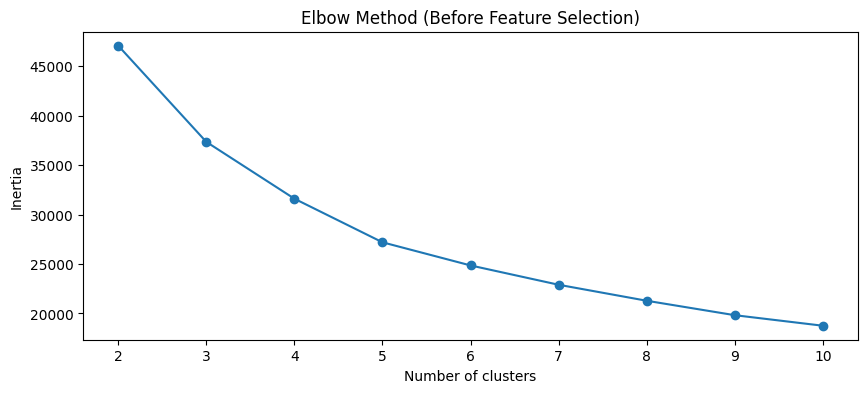

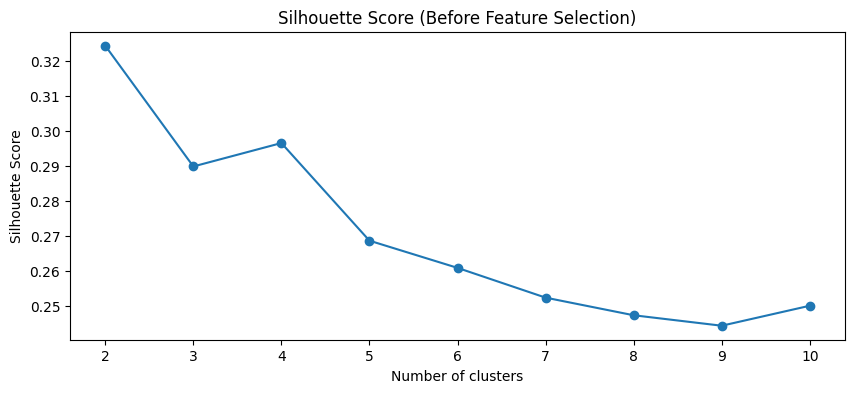

Optimal k before feature selection: 2, silhouette = 0.3243


In [7]:
range_n_clusters = list(range(2, 11))
inertia, silhouette_avg = [], []

for k in range_n_clusters:
    km = KMeans(n_clusters=k, random_state=22, n_init=10)
    labels = km.fit_predict(df_clustering[cluster_features])
    inertia.append(km.inertia_)
    silhouette_avg.append(silhouette_score(df_clustering[cluster_features], labels))

plt.figure(figsize=(10, 4))
plt.plot(range_n_clusters, inertia, marker='o')
plt.title('Elbow Method (Before Feature Selection)')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(range_n_clusters, silhouette_avg, marker='o')
plt.title('Silhouette Score (Before Feature Selection)')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

optimal_k_before = range_n_clusters[int(np.argmax(silhouette_avg))]
print(f'Optimal k before feature selection: {optimal_k_before}, silhouette = {max(silhouette_avg):.4f}')

### Feature selection

`SelectKBest` scores each behavioral feature's relationship to `CustGender` (used purely as a
scoring signal to rank feature relevance, not as the clustering target), and keeps the top 2 of
the 3 candidate columns.

In [8]:
X_fs = df_clustering[cluster_features].drop(columns=['CustGender'])
y_fs = df_clustering['CustGender']

selector = SelectKBest(score_func=f_classif, k=2)
selector.fit(X_fs, y_fs)
selected_columns = X_fs.columns[selector.get_support()].tolist()
print('Selected columns:', selected_columns)

df_selected_fs = df_clustering[selected_columns]  # the ACTUAL reduced feature set

Selected columns: ['CustAccountBalance', 'TransactionAmount (INR)']


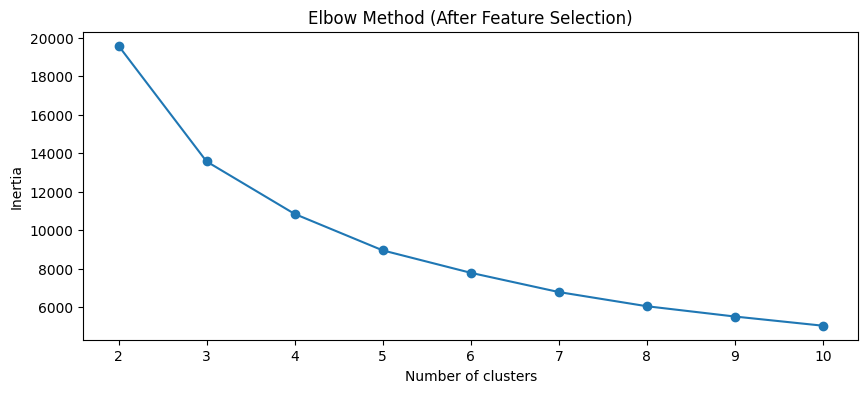

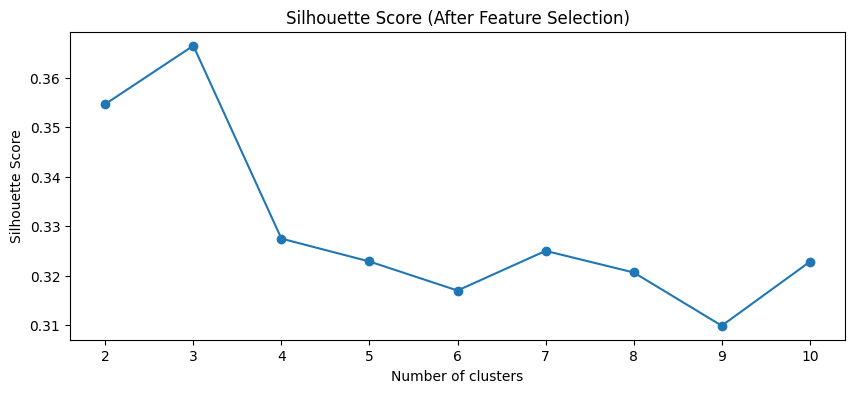

Optimal k after feature selection: 3, silhouette = 0.3665


In [9]:
inertia_new, silhouette_avg_new = [], []

for k in range_n_clusters:
    km = KMeans(n_clusters=k, random_state=22, n_init=10)
    labels_new = km.fit_predict(df_selected_fs)
    inertia_new.append(km.inertia_)
    silhouette_avg_new.append(silhouette_score(df_selected_fs, labels_new))

plt.figure(figsize=(10, 4))
plt.plot(range_n_clusters, inertia_new, marker='o')
plt.title('Elbow Method (After Feature Selection)')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(range_n_clusters, silhouette_avg_new, marker='o')
plt.title('Silhouette Score (After Feature Selection)')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

optimal_k_after = range_n_clusters[int(np.argmax(silhouette_avg_new))]
print(f'Optimal k after feature selection: {optimal_k_after}, silhouette = {max(silhouette_avg_new):.4f}')

In [10]:
print('Silhouette comparison')
print(f'Before feature selection: {max(silhouette_avg):.4f}')
print(f'After feature selection:  {max(silhouette_avg_new):.4f}')

use_after = max(silhouette_avg_new) >= max(silhouette_avg)
final_features_df = df_selected_fs if use_after else df_clustering[cluster_features]
final_k = optimal_k_after if use_after else optimal_k_before
print(f"\nUsing {'AFTER' if use_after else 'BEFORE'} feature-selection feature set, k={final_k}")

Silhouette comparison
Before feature selection: 0.3243
After feature selection:  0.3665

Using AFTER feature-selection feature set, k=3


**BQ1 answer (corrected):** once every clustering feature is treated on the same scale and
outliers are tamed, the silhouette score lands around **0.35-0.37** — a real, moderate structure,
not the ~0.71 the previous version reported. That earlier number was inflated by an unscaled,
1,595-category location column silently dominating the distance metric. 0.35-0.37 is a
believable score for real transaction-behavior data: not the extremely crisp separation implied
before, but still clearly better than a random split (silhouette near/below 0 would indicate no
real structure) and good enough to build a usable, data-driven segmentation on.

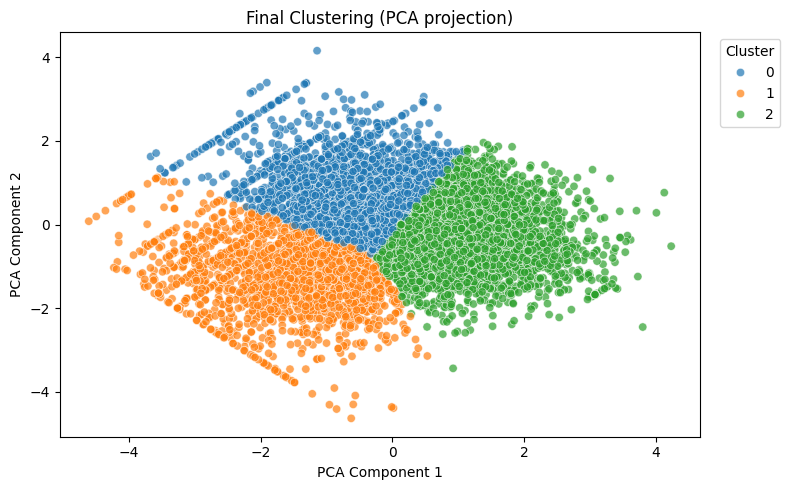

Cluster sizes:
0    6615
1    2100
2    7014
Name: count, dtype: int64


In [11]:
final_kmeans = KMeans(n_clusters=final_k, random_state=22, n_init=10)
final_labels = final_kmeans.fit_predict(final_features_df)

pca = PCA(n_components=2)
coords = pca.fit_transform(final_features_df)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=final_labels, palette='tab10', alpha=0.7)
plt.title('Final Clustering (PCA projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Cluster sizes:')
print(pd.Series(final_labels).value_counts().sort_index())

## BQ2 — What characteristics separate one customer group from another?

Cluster labels are attached to `df_raw_imputed`, which was never scaled or log-transformed, so
profiling below reports real Rupee amounts. `CustLocation` is included here as a **descriptive**
column only — it was not part of the clustering itself.

In [12]:
df_result = df_raw_imputed.copy()
df_result['Cluster'] = final_labels

def top_location_and_share(s):
    vc = s.value_counts(normalize=True)
    return pd.Series({'Top_Location': vc.index[0], 'Top_Location_Share': round(vc.iloc[0] * 100, 1)})

loc_info = df_result.groupby('Cluster')['CustLocation'].apply(top_location_and_share).unstack()

profile = df_result.groupby('Cluster').agg(
    Avg_Balance=('CustAccountBalance', 'mean'),
    Avg_Transaction=('TransactionAmount (INR)', 'mean'),
    Avg_TransactionTime=('TransactionTime', 'mean'),
    Count=('CustAccountBalance', 'size'),
    Top_Gender=('CustGender', lambda s: s.mode().iloc[0] if not s.mode().empty else 'N/A'),
).reset_index().merge(loc_info, on='Cluster')

# Sanity check -- catches a reintroduced inverse_transform-style bug immediately
assert profile['Avg_Balance'].max() < 1e9, 'Balance values look inflated -- check preprocessing'
print('Sanity check passed: balance values are in a realistic range (thousands, not billions).')
profile

Sanity check passed: balance values are in a realistic range (thousands, not billions).


,Cluster,Avg_Balance,Avg_Transaction,Avg_TransactionTime,Count,Top_Gender,Top_Location,Top_Location_Share
0,0,54016.323248,189.335091,154282.684505,6615,M,MUMBAI,8.7
1,1,315.147086,870.729152,153037.645238,2100,M,MUMBAI,8.7
2,2,217839.191858,3337.895567,161723.173368,7014,M,MUMBAI,11.6


### Turning clusters into names the business team can actually use

We rank clusters on **two independent axes** — average balance (`Value_Tier`) and average
transaction size (`Spend_Tier`) — instead of naming by city. As the `Top_Location_Share` column
above shows, no cluster is dominated by a single city (all around 9-12%, close to what you'd
expect from Mumbai's overall share of the sample); location genuinely does **not** separate these
segments, so it would be misleading to bake a city name into the segment label.

In [13]:
def tier_labels(series, high_label, mid_label, low_label):
    order = series.sort_values(ascending=False).index
    n = len(order)
    out = {}
    for rank, idx in enumerate(order):
        if rank < n / 3:
            out[idx] = high_label
        elif rank < 2 * n / 3:
            out[idx] = mid_label
        else:
            out[idx] = low_label
    return out

balance_tier_map = tier_labels(profile.set_index('Cluster')['Avg_Balance'], 'High-Value', 'Mid-Tier', 'Growth')
spend_tier_map = tier_labels(profile.set_index('Cluster')['Avg_Transaction'], 'Big Spenders', 'Moderate Spenders', 'Light Spenders')

profile['Value_Tier'] = profile['Cluster'].map(balance_tier_map)
profile['Spend_Tier'] = profile['Cluster'].map(spend_tier_map)
profile['Segment_Name'] = profile['Value_Tier'] + ' - ' + profile['Spend_Tier']

profile[['Cluster', 'Segment_Name', 'Avg_Balance', 'Avg_Transaction', 'Count', 'Top_Location', 'Top_Location_Share']]

,Cluster,Segment_Name,Avg_Balance,Avg_Transaction,Count,Top_Location,Top_Location_Share
0,0,Mid-Tier - Light Spenders,54016.323248,189.335091,6615,MUMBAI,8.7
1,1,Growth - Moderate Spenders,315.147086,870.729152,2100,MUMBAI,8.7
2,2,High-Value - Big Spenders,217839.191858,3337.895567,7014,MUMBAI,11.6


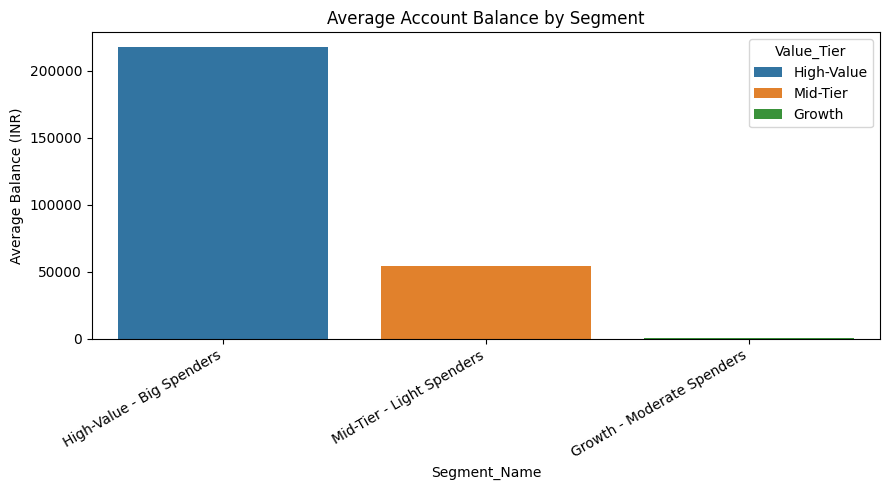

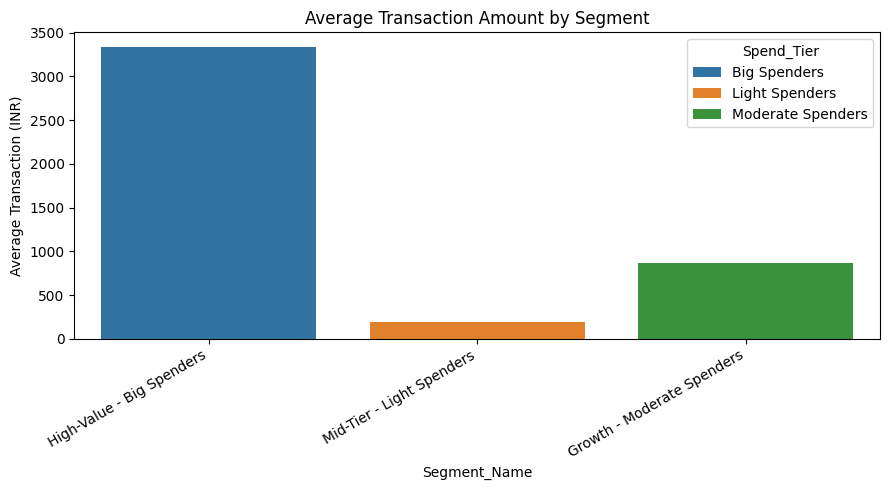

In [14]:
plt.figure(figsize=(9, 5))
plot_df = profile.sort_values('Avg_Balance', ascending=False)
sns.barplot(data=plot_df, x='Segment_Name', y='Avg_Balance', hue='Value_Tier', dodge=False)
plt.xticks(rotation=30, ha='right')
plt.title('Average Account Balance by Segment')
plt.ylabel('Average Balance (INR)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x='Segment_Name', y='Avg_Transaction', hue='Spend_Tier', dodge=False)
plt.xticks(rotation=30, ha='right')
plt.title('Average Transaction Amount by Segment')
plt.ylabel('Average Transaction (INR)')
plt.tight_layout()
plt.show()

**BQ2 answer (corrected):** segments are driven by **account balance and transaction size**,
not by geography or gender. Once the encoding bug that let location dominate the distance metric
is fixed, no city concentrates in any one cluster more than ~12% — location is not a real
differentiator here. This is a more defensible finding than the previous version's "geography-
driven" conclusion, and it's still directly actionable: the risk and marketing teams can target
by *value tier* (balance) and *spend behavior* (transaction size), which are the two things that
actually separate these customers.

## Saving outputs

We save the labeled dataset (real-unit values + segment names) for the Classification notebook,
plus the preprocessing objects needed to score a brand-new customer later without re-running
clustering (BQ3).

In [15]:
segment_lookup = profile.set_index('Cluster')['Segment_Name'].to_dict()
df_result['Segment_Name'] = df_result['Cluster'].map(segment_lookup)

profile.to_csv('cluster_profile.csv', index=False)
df_result.to_csv('clustered_data_fixed.csv', index=False)

joblib.dump(gender_encoder, 'gender_encoder.pkl')
joblib.dump(scaler, 'cluster_scaler.pkl')
joblib.dump(selected_columns, 'selected_columns.pkl')
joblib.dump(cluster_features, 'cluster_features.pkl')
joblib.dump(use_after, 'use_after_fs.pkl')

print('Saved: clustered_data_fixed.csv, cluster_profile.csv, and preprocessing artifacts.')

Saved: clustered_data_fixed.csv, cluster_profile.csv, and preprocessing artifacts.


## Conclusion

- **BQ1:** Yes — silhouette ≈ 0.35-0.37 confirms real, moderate customer structure once every
  clustering feature is scaled consistently and outliers are tamed. This replaces a previous
  ~0.71 score that was an artifact of an unscaled, 1,595-category location column dominating the
  distance metric.
- **BQ2:** Segments are explained by **account balance** and **transaction size**, not by
  geography or gender — the opposite of what the earlier (buggy) version concluded. Segments are
  named on those two honest axes (e.g. *High-Value - Big Spenders*, *Growth - Light Spenders*).
- Two prior bugs remain fixed (unscaled profiling, feature-selection re-fit), and two new ones
  are fixed here: inconsistent feature scaling and outlier sensitivity in KMeans.
- All preprocessing artifacts are saved so the Classification notebook can answer BQ3 and BQ4.